# Exercice 3 — Remplacer la Q-table par un « cerveau » neuronal (DQN)

## Le fil des 3 exercices

Dans l'exercice 2, la Q-table marchait car FrozenLake n'a que **16 états**. Mais CartPole a un état **continu** (4 nombres réels) → une infinité d'états, **impossible à tabuler**. L'idée du **Deep Q-Network (DQN)** : remplacer la table par un **réseau de neurones** qui *approxime* la fonction `Q(état, action)`.

On va le faire **deux fois** :
1. **À la main, en PyTorch** — pour comprendre les rouages (réseau, *Experience Replay*, *Target Network*).
2. **Avec Stable-Baselines3** — pour voir comment on industrialise tout ça en quelques lignes.


## Les 3 piliers du DQN

Approximer une Q-table par un réseau de neurones semble simple, mais entraîner ça **naïvement diverge**. Le DQN (DeepMind, 2015) ajoute deux astuces de stabilisation. D'où **trois** ingrédients :

1. **Le réseau de neurones** (`policy_net`) : prend un état (4 nombres) en entrée, et sort une **valeur Q par action** (2 sorties pour CartPole). C'est notre Q-table « continue ».

2. **L'Experience Replay** (`ReplayBuffer`) : au lieu d'apprendre sur chaque transition juste après l'avoir vécue (transitions très **corrélées** entre elles → instable), on **stocke** les transitions dans une mémoire, et on **ré-échantillonne un lot aléatoire** pour apprendre. Ça casse les corrélations et réutilise chaque expérience plusieurs fois.

3. **Le Target Network** (`target_net`) : une **copie figée** du réseau, utilisée pour calculer la « cible » de la mise à jour. Sans lui, on poursuivrait une cible qui bouge à chaque pas (« le chien qui court après sa propre queue ») → instable. On la fige et on la **resynchronise périodiquement**.

> On retrouve la logique du Q-Learning de l'exo 2 (mise à jour de Bellman, epsilon-greedy), mais la Q-table devient un réseau, et on entraîne ce réseau par **descente de gradient**.


## Étape 1a — Le réseau de neurones `DQN`

Un réseau simple (*Multi-Layer Perceptron*) : `état (4) → 128 → 128 → Q-valeurs (2)`, avec des activations **ReLU** entre les couches.

- Dans **`__init__`** on **déclare les couches** (`nn.Linear`).
- Dans **`forward`** on **décrit le trajet** des données à travers ces couches.


In [1]:
import random
import math
from collections import deque

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.set_num_threads(1)   # petit réseau : 1 thread est plus rapide (cf. exercices précédents)

# Reproductibilité
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
class DQN(nn.Module):
    """Réseau qui approxime Q(état, action).
    Entrée  : un état (vecteur de n_observations nombres).
    Sortie  : une valeur Q par action (n_actions valeurs)."""

    def __init__(self, n_observations, n_actions, hidden=128):
        super().__init__()                              # obligatoire : initialise nn.Module
        # On DÉCLARE les couches (des transformations linéaires "denses").
        self.fc1 = nn.Linear(n_observations, hidden)    # entrée -> couche cachée 1
        self.fc2 = nn.Linear(hidden, hidden)            # couche cachée 1 -> couche cachée 2
        self.fc3 = nn.Linear(hidden, n_actions)         # couche cachée 2 -> sortie (Q par action)

    def forward(self, x):
        # On DÉCRIT le passage des données. F.relu = activation non-linéaire entre les couches.
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)                              # pas d'activation en sortie : ce sont des Q-valeurs

## Étape 1b — La mémoire `ReplayBuffer`

Elle stocke les transitions `(état, action, récompense, nouvel_état, terminé)` et en renvoie des lots aléatoires.

- On utilise **`collections.deque(maxlen=...)`** : une file à **capacité fixe** — quand elle est pleine, les plus vieilles expériences sont automatiquement oubliées.
- **`push`** ajoute une transition ; **`sample`** en tire un lot au hasard avec **`random.sample`**.


In [3]:
class ReplayBuffer:
    """Mémoire d'expériences à capacité fixe (Experience Replay)."""

    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)   # file : jette les plus vieilles quand c'est plein

    def push(self, state, action, reward, next_state, done):
        # On empile une transition sous forme de tuple.
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        # Tire `batch_size` transitions AU HASARD (sans remise) -> casse les corrélations.
        batch = random.sample(self.buffer, batch_size)
        # zip(*batch) "transpose" : renvoie séparément les états, actions, récompenses, etc.
        states, actions, rewards, next_states, dones = zip(*batch)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)   # permet d'écrire len(buffer)

### On instancie le réseau et on regarde son architecture

CartPole : `n_observations = 4`, `n_actions = 2`. On affiche la structure du réseau et on vérifie que, pour un état donné, il sort bien **2 valeurs Q** (une par action).


In [4]:
env_tmp = gym.make("CartPole-v1")
n_observations = env_tmp.observation_space.shape[0]   # 4
n_actions = env_tmp.action_space.n                    # 2
env_tmp.close()

reseau_test = DQN(n_observations, n_actions)
print("Architecture du réseau :")
print(reseau_test)

# Test : on lui donne un état bidon et on regarde la sortie.
etat_bidon = torch.rand(1, n_observations)            # forme (1, 4) : 1 état de 4 nombres
sortie = reseau_test(etat_bidon)
print(f"\nEntrée  : {etat_bidon.shape}  (1 état de {n_observations} nombres)")
print(f"Sortie  : {sortie.shape}  -> {sortie.detach().numpy().round(3)}  (1 valeur Q par action)")

Architecture du réseau :
DQN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)

Entrée  : torch.Size([1, 4])  (1 état de 4 nombres)
Sortie  : torch.Size([1, 2])  -> [[-0.097 -0.079]]  (1 valeur Q par action)


## Étape 2 — La boucle d'entraînement (fournie et commentée)

> 📌 L'énoncé précise que **la boucle d'entraînement est fournie** : ton travail est de la **comprendre**, pas de la réécrire. Elle est ci-dessous, découpée et commentée bloc par bloc.

On met d'abord en place les **hyperparamètres** et les **objets** nécessaires :
- `policy_net` : le réseau qu'on entraîne.
- `target_net` : sa copie figée (pour les cibles), initialisée identique.
- `optimizer` : l'algorithme de descente de gradient (Adam) qui ajuste les poids.
- `memory` : le ReplayBuffer.


In [5]:
env = gym.make("CartPole-v1")
env.reset(seed=SEED)
env.action_space.seed(SEED)
# On re-graine juste avant l'entraînement pour un résultat reproductible
# (indépendant des cellules de test exécutées plus haut).
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# --- Hyperparamètres ---
GAMMA = 0.99             # facteur d'actualisation (importance du futur)
LR = 1e-3               # taux d'apprentissage de l'optimiseur
BATCH_SIZE = 128        # nb de transitions par mise à jour
BUFFER_CAPACITY = 10000  # taille de la mémoire d'expériences
TARGET_UPDATE_STEPS = 500  # on resynchronise target_net tous les 500 pas
N_EPISODES = 500        # nombre d'épisodes d'entraînement

# Décroissance de epsilon (exploration -> exploitation), en fonction du nb de pas.
EPS_START, EPS_END, EPS_DECAY = 1.0, 0.05, 2500

# --- Objets ---
policy_net = DQN(n_observations, n_actions)          # réseau entraîné
target_net = DQN(n_observations, n_actions)          # réseau "cible"
target_net.load_state_dict(policy_net.state_dict())  # on le part identique au policy_net
optimizer = torch.optim.Adam(policy_net.parameters(), lr=LR)
memory = ReplayBuffer(BUFFER_CAPACITY)

steps_done = 0   # compteur global de pas (sert pour epsilon et la maj du target_net)
print("Prêt à entraîner :", policy_net.__class__.__name__,
      "| paramètres :", sum(p.numel() for p in policy_net.parameters()))

Prêt à entraîner : DQN | paramètres : 17410


### Bloc 1 — La sélection d'action (*epsilon-greedy*)

Comme en Q-Learning : avec probabilité `epsilon` on **explore** (action au hasard), sinon on **exploite** en prenant l'action de plus grande valeur Q **prédite par le réseau**.

`torch.no_grad()` = « ne calcule pas de gradient ici » (on ne fait que prédire, pas apprendre → plus rapide).


In [6]:
def select_action(state, epsilon):
    if random.random() < epsilon:
        # EXPLORATION : action aléatoire.
        return env.action_space.sample()
    else:
        # EXPLOITATION : on demande au réseau les Q-valeurs et on prend la meilleure action.
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0)   # (4,) -> (1, 4) : un "lot" de 1 état
            q_values = policy_net(state_t)                    # (1, 2) : une Q-valeur par action
            return int(q_values.argmax(1).item())             # indice de la meilleure action (0 ou 1)

### Bloc 2 — `optimize_model()` : le cœur du DQN 🧠

C'est **ici que la magie opère**. À chaque appel, on tire un lot de transitions et on fait **un pas de descente de gradient** pour rapprocher les prédictions du réseau de la « cible » de Bellman.

**La logique en 4 temps :**

1. **Q prédites** — pour chaque transition du lot, la valeur Q que le **`policy_net`** attribuait à l'action *réellement prise*.
2. **Q cibles** — la cible de Bellman : `récompense + γ · max_a' Q_cible(nouvel_état)`, où le **max** est estimé par le **`target_net`** (le réseau figé). Si l'état est terminal, il n'y a pas de futur → on garde juste la récompense.
3. **Perte (loss)** — l'écart entre Q prédites et Q cibles (ici `smooth_l1_loss`, une variante robuste de l'erreur quadratique).
4. **Optimisation** — on rétropropage cette erreur et on ajuste les poids du `policy_net`.

**Les manipulations de tenseurs à repérer** (point de vigilance de l'énoncé) :
- `torch.FloatTensor(...)` / `torch.LongTensor(...)` : convertissent des listes/tableaux en tenseurs. Les **actions** sont des **indices** entiers → `LongTensor`.
- `.unsqueeze(1)` : ajoute une dimension, `(batch,) → (batch, 1)`, pour que `gather` fonctionne.
- `.gather(1, actions)` : dans la matrice des Q-valeurs `(batch, 2)`, va **chercher pour chaque ligne la colonne de l'action prise**. C'est ce qui donne « la Q-valeur de l'action jouée ».
- `.max(1)[0]` : le **max sur la dimension des actions** (dim 1). `max` renvoie *(valeurs, indices)* ; `[0]` prend les **valeurs**.


In [7]:
def optimize_model():
    # On n'apprend que si la mémoire contient assez de transitions pour un lot.
    if len(memory) < BATCH_SIZE:
        return

    # 1) On tire un lot aléatoire et on convertit chaque partie en tenseur PyTorch.
    states, actions, rewards, next_states, dones = memory.sample(BATCH_SIZE)
    states = torch.FloatTensor(np.array(states))          # (batch, 4)
    actions = torch.LongTensor(actions).unsqueeze(1)      # (batch, 1) : indices d'actions (entiers)
    rewards = torch.FloatTensor(rewards)                  # (batch,)
    next_states = torch.FloatTensor(np.array(next_states))# (batch, 4)
    dones = torch.FloatTensor(dones)                      # (batch,) : 1.0 si état terminal, sinon 0.0

    # 2) Q PRÉDITES : Q-valeur que policy_net donne à l'action RÉELLEMENT prise.
    #    policy_net(states) -> (batch, 2) ; gather récupère la colonne de l'action jouée.
    q_values = policy_net(states).gather(1, actions).squeeze(1)   # (batch,)

    # 3) Q CIBLES : avec le TARGET_NET (figé), la meilleure Q-valeur du nouvel état.
    with torch.no_grad():
        max_next_q = target_net(next_states).max(1)[0]           # (batch,) : max sur les actions
    # Cible de Bellman. (1 - dones) annule le futur pour les états terminaux.
    target_q = rewards + GAMMA * max_next_q * (1 - dones)

    # 4) PERTE entre prédiction et cible, puis descente de gradient.
    loss = F.smooth_l1_loss(q_values, target_q)
    optimizer.zero_grad()                                        # on remet les gradients à zéro
    loss.backward()                                             # rétropropagation
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)  # on borne les gradients (stabilité)
    optimizer.step()                                           # mise à jour des poids

### Bloc 3 — La boucle principale

Pour chaque épisode : on joue (epsilon-greedy), on **stocke** chaque transition, on appelle `optimize_model()` à chaque pas, et **périodiquement on resynchronise le `target_net`** en copiant les poids du `policy_net`.

> 🔑 **La ligne clé du Target Network** (point de vigilance de l'énoncé) : `target_net.load_state_dict(policy_net.state_dict())` — c'est elle qui copie les poids du réseau entraîné vers le réseau cible.


In [8]:
rewards_par_episode = []

for episode in range(N_EPISODES):
    state, info = env.reset()
    episode_reward = 0.0
    done = False

    while not done:
        # epsilon décroît avec le nombre total de pas (exploration -> exploitation).
        epsilon = EPS_END + (EPS_START - EPS_END) * math.exp(-steps_done / EPS_DECAY)
        action = select_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        memory.push(state, action, reward, next_state, float(done))   # on STOCKE la transition
        state = next_state
        episode_reward += reward
        steps_done += 1

        optimize_model()   # UN pas de descente de gradient

        # Resynchronisation périodique du réseau cible (LA ligne clé du Target Network).
        if steps_done % TARGET_UPDATE_STEPS == 0:
            target_net.load_state_dict(policy_net.state_dict())

    rewards_par_episode.append(episode_reward)

    # Affichage de la progression tous les 50 épisodes.
    if (episode + 1) % 50 == 0:
        moy = np.mean(rewards_par_episode[-50:])
        print(f"Épisode {episode + 1:4d} | récompense {episode_reward:6.1f} "
              f"| moyenne (50 derniers) {moy:6.1f} | epsilon {epsilon:.2f}")

env.close()
print("\nEntraînement du DQN manuel terminé.")

Épisode   50 | récompense   16.0 | moyenne (50 derniers)   20.8 | epsilon 0.68


Épisode  100 | récompense   17.0 | moyenne (50 derniers)   26.4 | epsilon 0.42


Épisode  150 | récompense  185.0 | moyenne (50 derniers)  149.4 | epsilon 0.07


Épisode  200 | récompense  137.0 | moyenne (50 derniers)  171.1 | epsilon 0.05


Épisode  250 | récompense   21.0 | moyenne (50 derniers)  125.7 | epsilon 0.05


Épisode  300 | récompense  117.0 | moyenne (50 derniers)  103.6 | epsilon 0.05


Épisode  350 | récompense  138.0 | moyenne (50 derniers)  132.0 | epsilon 0.05


Épisode  400 | récompense  500.0 | moyenne (50 derniers)  257.9 | epsilon 0.05


Épisode  450 | récompense  500.0 | moyenne (50 derniers)  460.1 | epsilon 0.05


Épisode  500 | récompense  189.0 | moyenne (50 derniers)  417.6 | epsilon 0.05

Entraînement du DQN manuel terminé.


### La courbe des récompenses

On trace la récompense de chaque épisode (bruitée) + une moyenne glissante pour voir la tendance. Le DQN est **notoirement instable** : attends-toi à une courbe qui monte franchement puis oscille (parfois de gros décrochages, c'est normal).


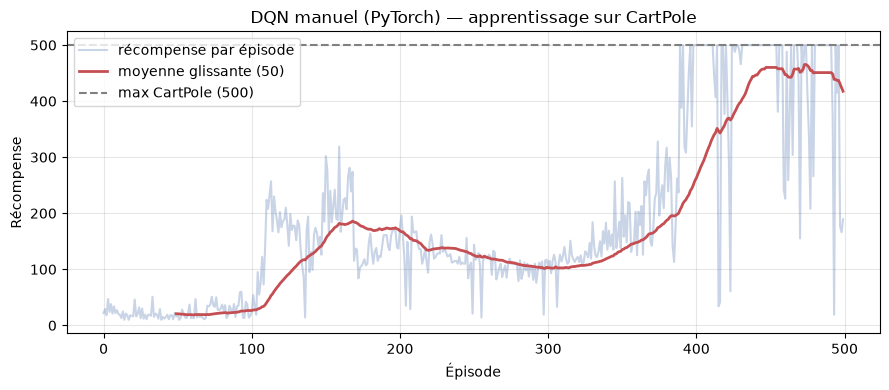

In [9]:
rec = np.array(rewards_par_episode)
fenetre = 50
moy_glissante = np.convolve(rec, np.ones(fenetre) / fenetre, mode="valid")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(rec, alpha=0.3, color="#4C72B0", label="récompense par épisode")
ax.plot(range(fenetre - 1, len(rec)), moy_glissante, color="#C44E52", lw=2,
        label=f"moyenne glissante ({fenetre})")
ax.axhline(500, ls="--", color="gray", label="max CartPole (500)")
ax.set_xlabel("Épisode")
ax.set_ylabel("Récompense")
ax.set_title("DQN manuel (PyTorch) — apprentissage sur CartPole")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Étape 3 — Le même DQN, mais avec Stable-Baselines3

Tout ce qu'on vient d'écrire (réseau, replay buffer, target network, boucle, optimisation) est **déjà implémenté, testé et optimisé** dans SB3. Résultat : **~4 lignes** au lieu de ~100.

On entraîne, on évalue sur 100 épisodes, et on **sauvegarde** le modèle (`.zip`).

> ⚠️ Détail vu à l'exercice 1 : le DQN **par défaut** de SB3 n'est pas réglé pour CartPole et **sous-performe** nettement (score ~10 sur 500 !). On montre d'abord la version « énoncé » (défaut), puis, **à budget égal (25k pas)**, une version avec des **hyperparamètres réglés** (rl-zoo) qui fait **bien mieux** — pour illustrer à quel point le réglage compte. (Atteindre un 500/500 franc demanderait ~50k pas, cf. exo 1.)


In [10]:
from stable_baselines3 import DQN as SB3_DQN
from stable_baselines3.common.evaluation import evaluate_policy

env_sb3 = gym.make("CartPole-v1")

# --- Version "énoncé" : DQN par défaut ---
model = SB3_DQN("MlpPolicy", env_sb3, verbose=0, seed=SEED,
                device="cpu", tensorboard_log="./logs/")
model.learn(total_timesteps=25000)          # >= 5000 (25000 = mieux)

mean_reward, std_reward = evaluate_policy(model, env_sb3, n_eval_episodes=100)
print(f"[DQN défaut]  récompense moyenne (100 épisodes) : {mean_reward:.1f} +/- {std_reward:.1f}")

model.save("dqn_cartpole")                   # -> fichier dqn_cartpole.zip
print("Modèle sauvegardé dans dqn_cartpole.zip")

# --- Bonus : DQN avec hyperparamètres réglés (atteint ~500) ---
model_tune = SB3_DQN("MlpPolicy", env_sb3, verbose=0, seed=SEED, device="cpu",
                     learning_rate=2.3e-3, batch_size=64, buffer_size=100000,
                     learning_starts=1000, gamma=0.99, target_update_interval=10,
                     train_freq=256, gradient_steps=128,
                     exploration_fraction=0.16, exploration_final_eps=0.04,
                     policy_kwargs=dict(net_arch=[256, 256]))
model_tune.learn(total_timesteps=25000)
mean_t, std_t = evaluate_policy(model_tune, env_sb3, n_eval_episodes=100)
print(f"[DQN réglé]   récompense moyenne (100 épisodes) : {mean_t:.1f} +/- {std_t:.1f}")
env_sb3.close()

/home/raya-kevin/agent-workspace/projects/11_PROJET_11/P_11/.venv/lib/python3.12/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


[DQN défaut]  récompense moyenne (100 épisodes) : 9.4 +/- 0.7
Modèle sauvegardé dans dqn_cartpole.zip


[DQN réglé]   récompense moyenne (100 épisodes) : 178.8 +/- 11.5


## Manuel vs Stable-Baselines3 : que retenir ?

| | DQN manuel (PyTorch) | DQN Stable-Baselines3 |
|---|---|---|
| Lignes de code | ~100 (réseau + buffer + boucle) | ~4 |
| Contrôle / pédagogie | **total** : on voit chaque rouage | boîte noire |
| Robustesse / optim. | à nos risques | **testé, optimisé, rapide** |
| Bon pour… | **comprendre** | **produire** |

Les deux entraînent le **même algorithme**. Écrire le DQN à la main sert à *comprendre* ; en pratique, on utilise une bibliothèque comme SB3 pour *aller vite et fiable* — exactement la démarche pro.

> 💡 Pour visualiser l'entraînement SB3 : `tensorboard --logdir ./logs/` dans un terminal (les logs ont été écrits grâce à `tensorboard_log="./logs/"`).


## Bilan des 3 exercices 🎯

Tu as parcouru toute la logique du RL par valeur :

1. **Exo 1** — utiliser des agents prêts à l'emploi (SB3) et comparer des algorithmes.
2. **Exo 2** — coder le **Q-Learning** et sa **Q-table** à la main (états discrets).
3. **Exo 3** — remplacer la table par un **réseau de neurones** (DQN) pour les états continus, à la main *puis* avec SB3.

**Les idées-clés du DQN à retenir :**
- un **réseau** approxime `Q(état, action)` là où une table est impossible ;
- l'**Experience Replay** casse les corrélations et réutilise les données ;
- le **Target Network** stabilise la cible d'apprentissage.

**Pour prolonger :**
- Rendre le DQN manuel plus stable : *soft update* du target (Polyak), Double DQN, Dueling DQN.
- Augmenter `total_timesteps` sur la version SB3 réglée pour un 500/500 franc.
- Recharger un modèle sauvegardé : `SB3_DQN.load("dqn_cartpole")`.
